## Subset CosMx dataset

This script is for subsetting the original dataset to a smaller region of interest. The subsetted dataset will be used for testing the downstream analysis pipeline.

We will restrict to around 1/9 of the cells in the original dataset, keeping a smaller region, with all the cells in those FOVs. 
Aiming for 20k to 30k cells in the subsetted dataset, which will be saved as a new h5ad file for downstream analysis.


This step was performed after running the first, preprocessing notebook, and prior to the annotation notebook. 

In [7]:
## sbatch --mem=100G -p tier2q  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial

## LIBRARIES
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from scipy.sparse import csr_matrix

In [8]:
## Load anndata. 

adata = sc.read_h5ad('./CosMx/results/BreastCancer/BreastCancer_filtered.h5ad')

In [9]:

## Get initial data
print(f"\nn_cells: {adata.n_obs:,}")
print(f"n_genes: {adata.n_vars:,}")

fov_counts = adata.obs['fov'].value_counts().sort_index()
# print(fov_counts)
print(f"\nTotal FOVs: {len(fov_counts)}")
print(f"Cells per FOV — min: {fov_counts.min()}, max: {fov_counts.max()}, mean: {fov_counts.mean():.0f}")


n_cells: 135,695
n_genes: 20,334

Total FOVs: 108
Cells per FOV — min: 32, max: 2909, mean: 1256


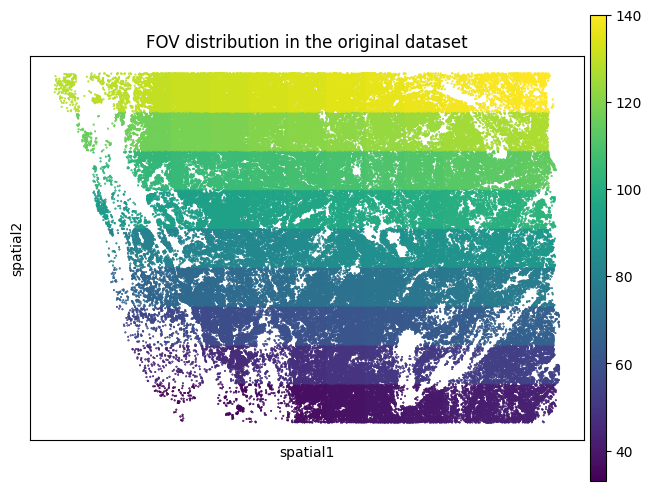

In [10]:
## Print the 
sq.pl.spatial_scatter(
    adata,
    color="fov",
    shape=None,
    size=0.5,
    title="FOV distribution in the original dataset",
)

In [11]:
adata

AnnData object with n_obs × n_vars = 135695 × 20334
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'CosMx', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 

In [12]:
## Define the subset of interest.
## Get describe from columns 'CenterX_global_px', 'CenterY_global_px'
x_min, x_max = adata.obs['CenterX_global_px'].describe()[['min', 'max']]
y_min, y_max = adata.obs['CenterY_global_px'].describe()[['min', 'max']]

print(f"x_min: {x_min}, x_max: {x_max}")
print(f"y_min: {y_min}, y_max: {y_max}")

x_min: 4563.0, x_max: 59823.0
y_min: 85278.0, y_max: 123555.0


In [13]:
## Coordinates. dictionary with keys 'x_min', 'x_max', 'y_min', 'y_max'
coords = {'x_min': x_min + (x_max - x_min)/3, 
        'x_max': x_min + 2*(x_max - x_min)/3, 
        'y_min': y_min + 2*(y_max - y_min)/9, 
        'y_max': y_min + 6*(y_max - y_min)/9}

## Find which are the FOVs that fall within the defined coordinates.
## filter adata.obs based on the coordinates and get the unique FOVs that fall within the coordinates.
fovs_in_coords = adata.obs[
    (adata.obs['CenterX_global_px'] >= coords['x_min']) &
    (adata.obs['CenterX_global_px'] <= coords['x_max']) &
    (adata.obs['CenterY_global_px'] >= coords['y_min']) &
    (adata.obs['CenterY_global_px'] <= coords['y_max'])
]['fov'].unique()

## Subset the data based on the coordinates.
subset_adata = adata[
    (adata.obs['fov'].isin(fovs_in_coords))
].copy()

In [14]:
subset_adata

AnnData object with n_obs × n_vars = 31999 × 20334
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'CosMx', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', '

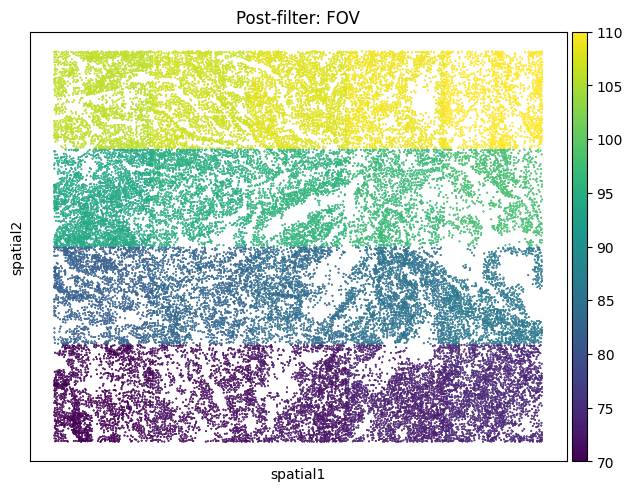

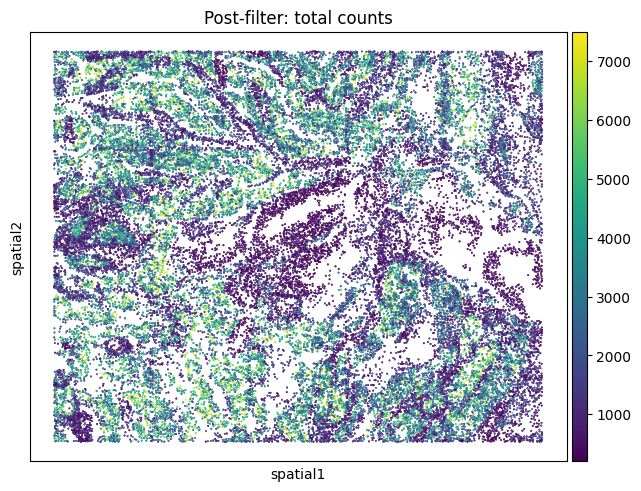

In [15]:
sq.pl.spatial_scatter(
    subset_adata,
    color="fov",
    shape=None,
    size=0.5,
    title="Post-filter: FOV",
)

sq.pl.spatial_scatter(
    subset_adata,
    color="total_counts",
    shape=None,
    size=0.5,
    title="Post-filter: total counts",
)

In [16]:
## Save the subsetted data.
subset_adata.write_h5ad('./CosMx/results/BreastCancer/BreastCancer_subset.h5ad')

We will save the counts, cell metadata and features in a mtx format, similar to 10x output. 

In [17]:
## Store key mtx tables to create Seurat object in R. 
import scipy.io

mtx_path = './CosMx/results/BreastCancer/Subset_MM'
Path(mtx_path).mkdir(parents=True, exist_ok=True)

# 1. Count matrix (genes x cells, as expected by Seurat)
scipy.io.mmwrite(f"{mtx_path}/matrix.mtx", subset_adata.X.T)

# 2. Cell barcodes
pd.DataFrame(subset_adata.obs_names).to_csv(
    f"{mtx_path}/barcodes.tsv", index=False, header=False
)

# 3. Features/genes
features = pd.DataFrame({
    "gene_id": subset_adata.var_names,          # or adata.var["gene_ids"] if available
    "gene_name": subset_adata.var_names,        # adjust if you have a "gene_name" column
    "feature_type": "Gene Expression"
})
features.to_csv(f"{mtx_path}/features.tsv", index=False, header=False, sep="\t")

# 4. Cell metadata
subset_adata.obs.to_csv(f"{mtx_path}/metadata.csv")